# Volatility Forecasting — Weekly Silver Realised Volatility

The other weekly notebooks all target the **weekly silver log-return**. Across ARIMA,
VAR, MIDAS, RF, XGBoost, and LSTM, the best WDA we have squeezed out is ≈ 0.59–0.62 on
test — roughly 60 % directional accuracy, with the simplest models often within
striking distance of the best. Return predictability for silver is, at best, weak.

**The question this chapter asks:** is **volatility** easier to forecast than direction?

Volatility clustering (Mandelbrot 1963; Engle 1982) is one of the most robust stylised
facts in financial time series — high-vol weeks cluster, low-vol weeks cluster. So even
when returns look like white noise, squared returns carry strong autocorrelation and
are forecastable. If silver vol is forecastable, that is a thesis-relevant finding (vol
forecasts feed risk management, option pricing, position sizing) even when returns are
not.

**A note on squared returns as a variance proxy.** By definition

$$\mathbb{E}[r_t^2] = \operatorname{Var}(r_t) + \big(\mathbb{E}[r_t]\big)^2,$$

so a squared return measures variance *plus* the squared mean. At daily and weekly
horizons the conditional mean of financial returns is very close to zero, so
$\mathbb{E}[r_t] \approx 0$ and therefore
$\mathbb{E}[r_t^2] \approx \operatorname{Var}(r_t)$. Using summed squared returns as
realised variance is standard precisely under this assumption — at these frequencies
volatility dominates the mean.

**Target** — weekly realised volatility from daily returns:

$$\text{RV}_t = \sqrt{\sum_{i \in \text{week } t} r_i^2}$$


## Setup


In [48]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load daily data and aggregate to weekly RV

Same `train.csv / val.csv / test.csv` as every other weekly notebook. For each asset
the daily returns are squared, summed within each W-FRI week, then square-rooted to
give weekly realised volatility.

**Why square daily returns and sum, rather than averaging daily volatilities?**
Realised *variance* is additive — the variance contribution of each day adds up over
the week — whereas volatility (a standard deviation) is not. So we sum daily squared
returns to get the weekly realised *variance*, and take the square root only at the
end to recover weekly realised *volatility*. Summing daily volatilities directly would
have no clean statistical meaning.

In [49]:
train = pd.read_csv('../../data/processed/train.csv', parse_dates=['Date']).set_index('Date')
val   = pd.read_csv('../../data/processed/val.csv',   parse_dates=['Date']).set_index('Date')
test  = pd.read_csv('../../data/processed/test.csv',  parse_dates=['Date']).set_index('Date')

ASSETS = ['silver_return', 'gold_return', 'copper_return', 'usd_return',
          'sp500_return', 'vix_return', 'oil_return']

daily = pd.concat([train[ASSETS], val[ASSETS], test[ASSETS]]).sort_index()

def weekly_rv(daily_rets):
    """Weekly realised volatility = sqrt of the summed daily squared returns."""
    return np.sqrt((daily_rets ** 2).resample('W-FRI').sum())

rv = pd.concat({a.replace('_return', '_rv'): weekly_rv(daily[a]) for a in ASSETS}, axis=1)
rv = rv.dropna()
print(f'Weekly RV obs: {len(rv)}  ({rv.index.min().date()} -> {rv.index.max().date()})')
rv.head()


Weekly RV obs: 591  (2015-01-09 -> 2026-05-01)


,silver_rv,gold_rv,copper_rv,usd_rv,sp500_rv,vix_rv,oil_rv
Date,,,,,,,
2015-01-09,0.039710,0.021906,0.018301,0.008919,0.030649,0.203221,0.069482
2015-01-16,0.054048,0.029461,0.064370,0.004825,0.019257,0.150161,0.101212
2015-01-23,0.019898,0.015792,0.029085,0.017460,0.016872,0.158786,0.066598
2015-01-30,0.081585,0.034358,0.041376,0.010309,0.025178,0.254896,0.092746
2015-02-06,0.032449,0.026310,0.035942,0.013249,0.022479,0.172626,0.125761


### 1.1 Variance-proxy check — a squared return measures variance

`weekly_rv` above sums squared returns, which estimates *variance* only up to the squared
mean: by definition $\mathbb{E}[r^2] = \operatorname{Var}(r) + (\mathbb{E}[r])^2$. The
cell below confirms numerically that the squared-mean term is negligible for silver at
both the daily (the RV building block) and weekly horizons, so $\mathbb{E}[r^2] \approx
\operatorname{Var}(r)$ and summed daily squared returns are a clean variance proxy. (This
is the empirical basis for treating $\text{RV}^2$ as realised variance.)

In [50]:
# Variance-proxy identity (exact):  E[r^2] = Var(r) + (E[r])^2.  RV sums squared returns,
# so it measures variance only when the squared-mean term is negligible. Confirm that for
# silver at the daily (RV building block) and weekly horizons.
def proxy_check(r, label):
    r = r.dropna()
    E_r2, Var_r, mean_sq = (r ** 2).mean(), r.var(ddof=0), r.mean() ** 2
    print(r.mean(), r.var(ddof=0), (r.mean() ** 2) / r.var(ddof=0))
    assert abs(E_r2 - (Var_r + mean_sq)) < 1e-18, 'identity broken'      # exact with ddof=0
    print(f'{label:7s} n={len(r):4d}   E[r^2]={E_r2:.3e}   Var(r)={Var_r:.3e}   '
          f'(E[r])^2={mean_sq:.2e}   (E[r])^2/Var={mean_sq / Var_r:.3%}')

proxy_check(daily['silver_return'],                         'daily')
proxy_check(daily['silver_return'].resample('W-FRI').sum(), 'weekly')

0.0005832192625962716 0.0004444187819877374 0.0007653697864477839
daily   n=2841   E[r^2]=4.448e-04   Var(r)=4.444e-04   (E[r])^2=3.40e-07   (E[r])^2/Var=0.077%
0.0028035971658815695 0.0018264874962336901 0.0043034278004898535
weekly  n= 591   E[r^2]=1.834e-03   Var(r)=1.826e-03   (E[r])^2=7.86e-06   (E[r])^2/Var=0.430%


### Notebook layout

This chapter is split the same way as the `weekly/` return notebooks — one shared
feature-build notebook, then one notebook per model, then an evaluation notebook:

| Notebook | Contents |
|---|---|
| `00_features.ipynb` (this one) | Load daily data, aggregate to weekly RV, EDA, build the HAR + EXOG feature frame, split → `volatility_weekly.csv` |
| `02_har.ipynb` | Naïve floor + HAR-RV (Corsi 2009) |
| `01_garch.ipynb` | GARCH(1,1) walk-forward |
| `03_random_forest.ipynb` | Random Forest on HAR + EXOG |
| `04_xgboost.ipynb` | XGBoost on HAR + EXOG |
| `evaluation.ipynb` | Cross-model table, sub-period breakdown, 2026 zoom, DM tests |

Every model notebook loads the single `volatility_weekly.csv` produced here, so the RV
target and feature definitions are guaranteed identical across models.

**Metrics** (defined in `src/vol_utils.py`): RMSE, MAE, $R^2$, and **DCA** —
Direction-of-Change Accuracy on $\Delta \log \text{RV}$, i.e. did the model correctly
call vol rising vs falling. DA/WDA from the return notebooks do not apply because
RV ≥ 0.


## 2. EDA — getting a picture of the target

Five diagnostics on weekly silver realised volatility, each motivating a downstream
modelling or evaluation choice elsewhere in the chapter:

| § | Diagnostic | Downstream choice it motivates |
|---|---|---|
| 2.1 | RV time series with regime markers | sub-period breakdown in `evaluation.ipynb`; visual context for the 2020 / 2021 / 2026 spikes |
| 2.2 | Distribution + QQ plot vs Normal | QLIKE as the proxy-robust DM loss — squared-error DM is dominated by the right tail |
| 2.3 | ACF of RV vs returns | HAR mixture-of-horizons construction in §3 (predictable second moment, unpredictable first) |
| 2.4 | Contemporaneous correlation heatmap (silver RV + 6 EXOG + 3 sentiment) | Co-movement among all candidate features; previews the multicollinearity that hurts `HAR+EXOG` and the combined-sentiment rung in `02_har` §5 |
| 2.5 | Lagged predictive correlation (predictors at $t{-}1$, silver RV at $t$) | Lead-lag correlation that drives HAR-X marginal predictive power — distinguishes predictive signal from contemporaneous co-movement |

### 2.1 RV time series with regime markers

Weekly silver RV across the full sample, with regime markers and split lines. The
annotated weeks are the spikes that show up in the per-year breakdown in
`evaluation.ipynb`; vertical dotted lines mark the train | val | test boundaries.

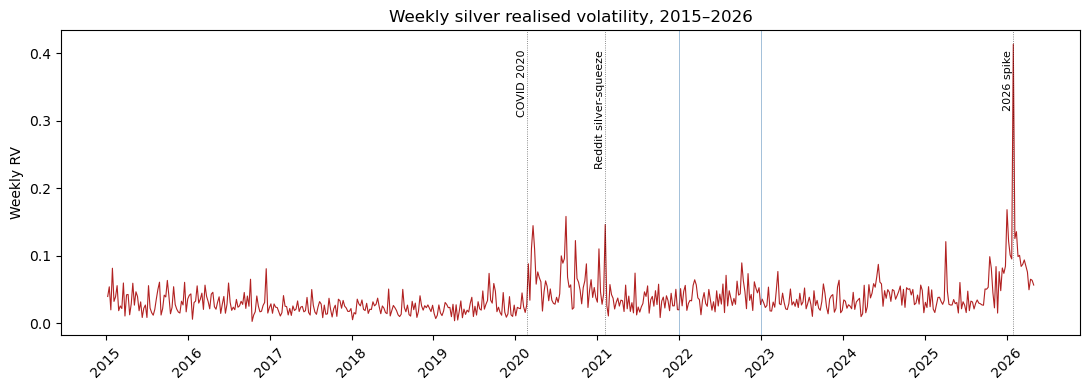

silver_rv: min=0.0028  median=0.0296  mean=0.0369  max=0.4136   max/median = 14.0x


In [51]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(rv.index, rv['silver_rv'], color='firebrick', lw=0.8)
ax.set_title('Weekly silver realised volatility, 2015–2026')
ax.set_ylabel('Weekly RV')

# Show every year on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ymax = rv['silver_rv'].max()

episodes = [
    (pd.Timestamp('2020-02-20'), 'COVID 2020'),
    (pd.Timestamp('2021-02-05'), 'Reddit silver-squeeze'),
    (rv.loc['2026']['silver_rv'].idxmax(), '2026 spike'),
]

for dt, lbl in episodes:
    ax.axvline(dt, color='black', ls=':', lw=0.6, alpha=0.6)
    ax.text(dt, ymax * 0.98, lbl, fontsize=8, ha='right', rotation=90, va='top')

for dt in ['2021-12-31', '2022-12-31']:
    ax.axvline(pd.Timestamp(dt), color='steelblue', lw=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"silver_rv: min={rv['silver_rv'].min():.4f}  "
      f"median={rv['silver_rv'].median():.4f}  "
      f"mean={rv['silver_rv'].mean():.4f}  "
      f"max={rv['silver_rv'].max():.4f}   "
      f"max/median = {rv['silver_rv'].max()/rv['silver_rv'].median():.1f}x")

### 2.2 Distribution and QQ plot vs Normal

Distribution of weekly silver RV (right-skewed, heavy upper tail) and the QQ plot vs
Normal. The right-tail departure is what kills squared-error DM power in
`evaluation.ipynb` section 4 -- a handful of upper-tail weeks dominate the loss
differential -- and is why QLIKE (Patton 2011) is the primary DM loss. (The markdown
cell after the plot covers how to read the QQ.)

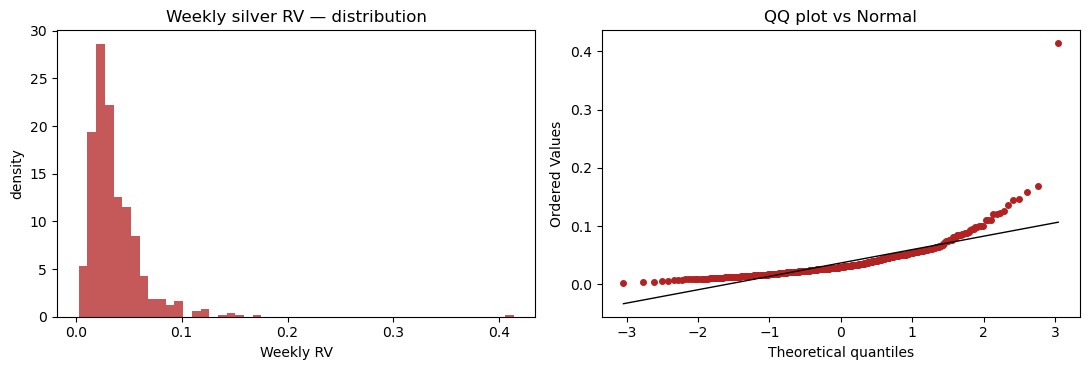

skewness        = +5.28   (Normal has 0)
excess kurtosis = +57.80   (Normal has 0)
95th pct = 0.0841   99th pct = 0.1266   max = 0.4136


In [52]:
from scipy import stats as scipy_stats

silver = rv['silver_rv'].dropna()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].hist(silver, bins=50, color='firebrick', alpha=0.75, density=True)
ax[0].set_title('Weekly silver RV — distribution')
ax[0].set_xlabel('Weekly RV'); ax[0].set_ylabel('density')

scipy_stats.probplot(silver, dist='norm', plot=ax[1])
ax[1].set_title('QQ plot vs Normal')
ax[1].get_lines()[0].set_markerfacecolor('firebrick')
ax[1].get_lines()[0].set_markeredgecolor('firebrick')
ax[1].get_lines()[0].set_markersize(4)
ax[1].get_lines()[1].set_color('black'); ax[1].get_lines()[1].set_linewidth(1)

plt.tight_layout(); plt.show()

print(f'skewness        = {silver.skew():+.2f}   (Normal has 0)')
print(f'excess kurtosis = {silver.kurtosis():+.2f}   (Normal has 0)')
print(f'95th pct = {silver.quantile(0.95):.4f}   '
      f'99th pct = {silver.quantile(0.99):.4f}   '
      f'max = {silver.max():.4f}')

**How to read the QQ plot above.** The Normal reference line passes through the bulk
of the points; the upper-tail points curve sharply *above* the line. That curvature is
the diagnostic — silver-RV's upper tail is much fatter than a Normal of the same
mean/variance would produce. Those extreme weeks are not "rare normal events"; they
are categorically more extreme than Gaussian sampling allows (excess kurtosis ≈ +58
above; Normal has 0).

This is exactly the property that destroys squared-error DM power in `evaluation.ipynb`
§4: a handful of upper-tail weeks carry squared errors orders of magnitude larger than
the rest, so they dominate the loss differential and inflate the DM variance even when
a model is steadily better on the typical weeks. QLIKE's log-ratio form down-weights
that tail and recovers the power MSE loses.

### Why QLIKE, not MSE — the math

Write $\sigma^2 = \text{RV}^2$ for the realised variance and $h = \widehat{\text{RV}}^2$
for the forecast variance. The two losses used in the volatility DM tests
(`src/vol_utils.py`) are:

$$L_{\text{MSE}}(\text{RV}, \widehat{\text{RV}}) = \big(\text{RV} - \widehat{\text{RV}}\big)^2
\qquad
L_{\text{QLIKE}}(\sigma^2, h) = \frac{\sigma^2}{h} - \log\frac{\sigma^2}{h} - 1$$

**MSE** is symmetric in the signed error $\text{RV} - \widehat{\text{RV}}$: an
over-forecast and an under-forecast of equal magnitude carry the same penalty.

**QLIKE** depends only on the ratio $r = \sigma^2 / h$ (minimised at $r = 1$) and is
asymmetric. As $r \to \infty$ — severe under-forecast of variance, $h \ll \sigma^2$ —
$L$ grows **linearly** in $r$; as $r \to 0$ — severe over-forecast, $h \gg \sigma^2$ —
$L$ grows only **logarithmically** in $1/r$. So QLIKE penalises under-forecasting of
variance more than over-forecasting, exactly the asymmetry risk management cares about
(undersized VaR / hedges are the costlier real-world error).

With $\sigma^2 = 1$:

| Forecast $h$ | Ratio $r = \sigma^2/h$ | $L_{\text{QLIKE}}$ |
|---|---|---|
| $h = 0.5$ (under-forecast ×2) | $2.0$ | **$0.307$** |
| $h = 1.0$ (perfect)            | $1.0$ | $0$ |
| $h = 2.0$ (over-forecast ×2)   | $0.5$ | $0.193$ |

Under-forecasting variance by a factor of 2 costs ≈ 60 % more QLIKE loss than
over-forecasting by the same factor.

The heavy upper tail visible in the histogram and QQ plot above is what motivates this
choice empirically: a handful of extreme-RV weeks dominate $L_{\text{MSE}}$ and inflate
the DM variance, while QLIKE's log-ratio form down-weights them.

### 2.3 ACF - weekly returns vs weekly RV

The chapter's headline EDA, in two bars: weekly silver *returns* ACF (left) vs weekly
silver *RV* ACF (right). Returns look like white noise -- no significant
autocorrelation at any lag -- while RV exhibits strong, slowly-decaying multi-week
persistence. The first moment is unforecastable; the second moment is. This is what
motivates HAR's mixture-of-horizons construction in section 3.

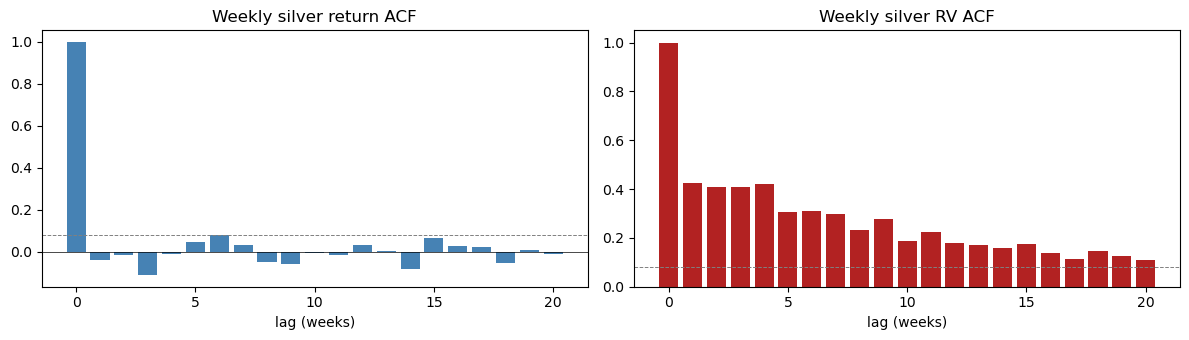

Return  ACF(1) = -0.041
RV      ACF(1) = +0.427
RV      ACF(4) = +0.422   <- multi-week persistence


In [53]:
silver_w_ret = daily['silver_return'].resample('W-FRI').sum().reindex(rv.index)
silver_rv    = rv['silver_rv']

n_lags = 20
acf_ret = acf(silver_w_ret.dropna(), nlags=n_lags, fft=True)
acf_rv  = acf(silver_rv.dropna(),    nlags=n_lags, fft=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(len(acf_ret)), acf_ret, color='steelblue'); ax[0].set_title('Weekly silver return ACF'); ax[0].axhline(0, color='k', lw=0.5)
ax[1].bar(range(len(acf_rv)),  acf_rv,  color='firebrick'); ax[1].set_title('Weekly silver RV ACF');     ax[1].axhline(0, color='k', lw=0.5)
for a in ax: a.set_xlabel('lag (weeks)'); a.axhline(2/np.sqrt(len(silver_rv)), color='grey', ls='--', lw=0.7)
plt.tight_layout(); plt.show()

print(f'Return  ACF(1) = {acf_ret[1]:+.3f}')
print(f'RV      ACF(1) = {acf_rv[1]:+.3f}')
print(f'RV      ACF(4) = {acf_rv[4]:+.3f}   <- multi-week persistence')


Alternatively we can plot like so

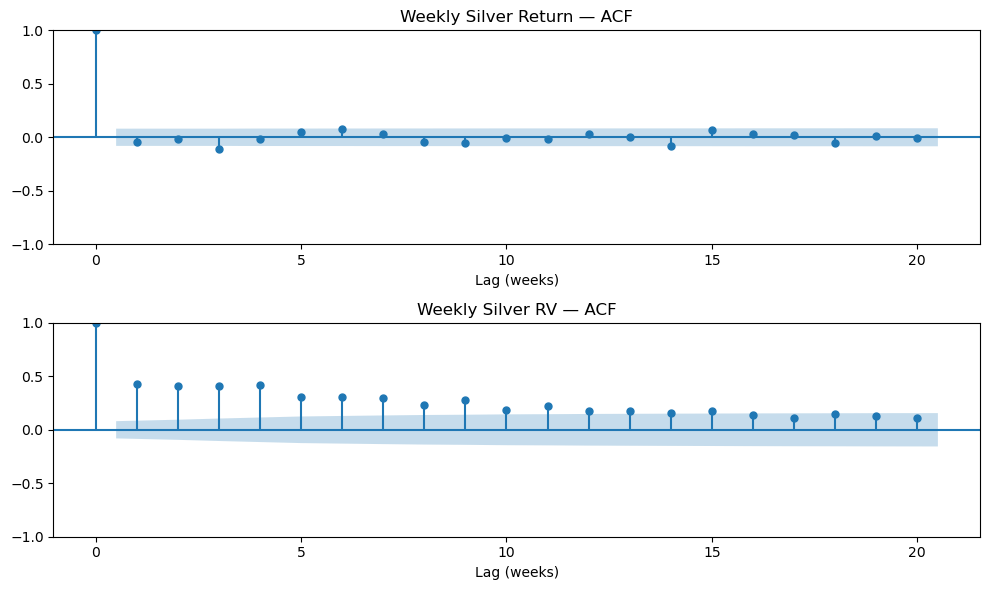

In [54]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(silver_w_ret.dropna(), ax=axes[0], lags=n_lags, title='Weekly Silver Return — ACF')
plot_acf(silver_rv.dropna(),    ax=axes[1], lags=n_lags, title='Weekly Silver RV — ACF')

for ax in axes:
    ax.set_xlabel('Lag (weeks)')

plt.tight_layout()
plt.show()

**Or, the full EDA battery in one call.** `src/eda_utils.py::eda_transform` packages
the standard EDA workflow — time-series plot, ACF/PACF, histogram + KDE + Normal PDF,
QQ-plot, ADF stationarity test, Ljung-Box on the level, and four normality tests
(Shapiro-Wilk, D'Agostino $K^2$, Anderson-Darling, Kolmogorov-Smirnov) — into a single
call. Running it on `silver_rv` corroborates the picture the hand-rolled cells above
paint: stationary in level (ADF rejects unit root), strongly non-Gaussian (every
normality test rejects), and the slowly-decaying ACF that motivates HAR.


No transform applied.


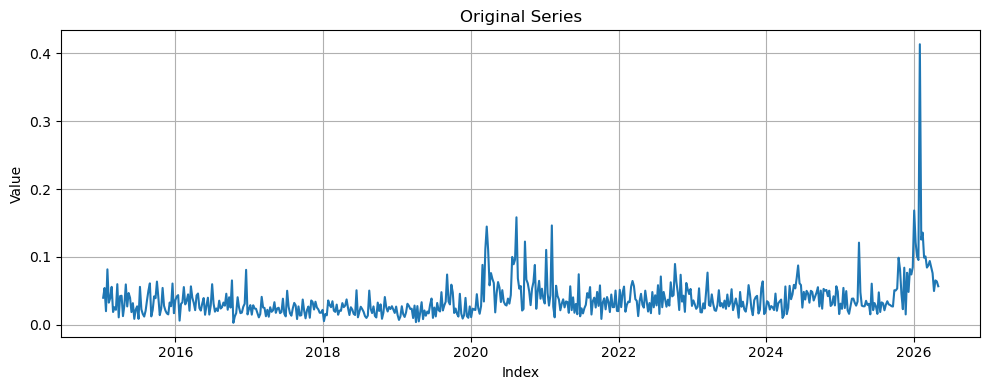

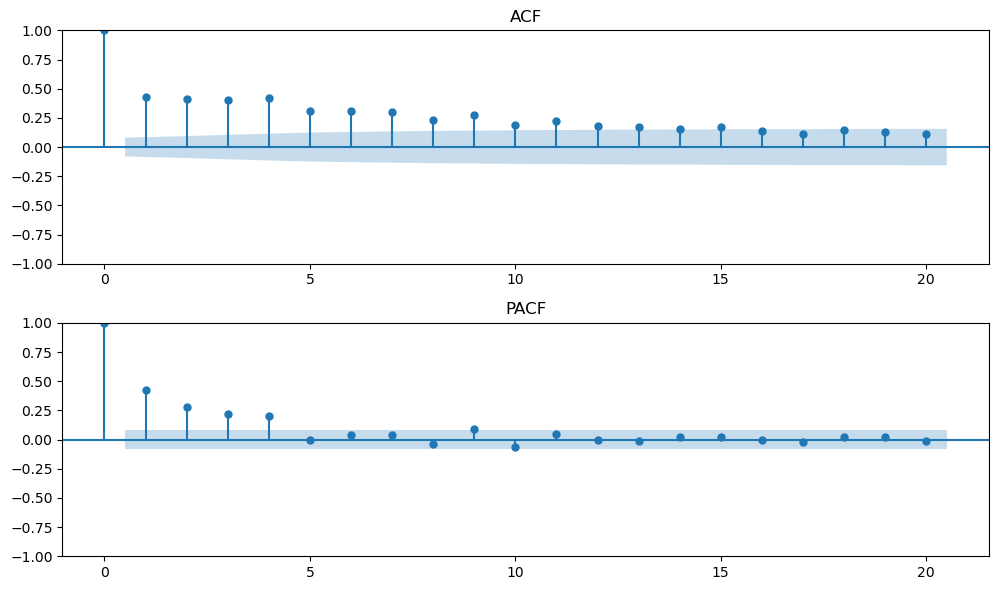

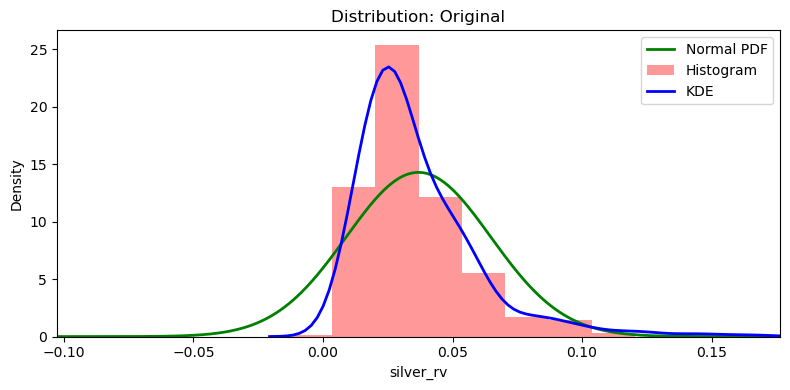

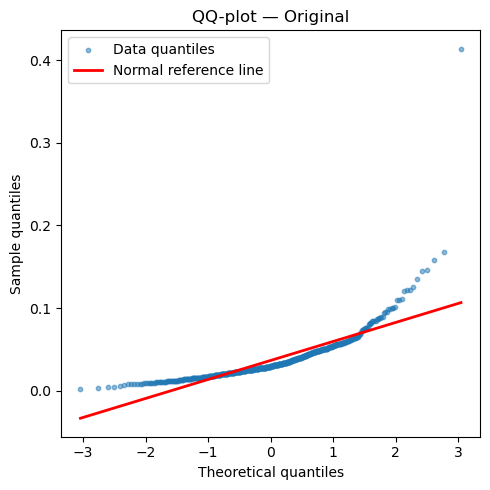

  QQ R²: 0.6719 (1.0 = perfect normal)

ADF Test:
  Statistic: -5.6241
  p-value:   0.0000
    1%: -3.4415
    5%: -2.8665
    10%: -2.5694
  → Stationary (reject H₀)

Ljung-Box:
  lag=2: p-value = 0.0000  → Autocorrelation present
  lag=4: p-value = 0.0000  → Autocorrelation present
  lag=6: p-value = 0.0000  → Autocorrelation present
  lag=8: p-value = 0.0000  → Autocorrelation present
  lag=10: p-value = 0.0000  → Autocorrelation present
  lag=12: p-value = 0.0000  → Autocorrelation present

Shapiro-Wilk:         stat=0.6787, p=0.0000  → NOT normal
D'Agostino K²:        stat=681.1477, p=0.0000  → NOT normal
Anderson-Darling:     stat=31.7309
     15.0%: 0.5600 ← reject normality
     10.0%: 0.6300 ← reject normality
      5.0%: 0.7510 ← reject normality
      2.5%: 0.8720 ← reject normality
      1.0%: 1.0340 ← reject normality
Kolmogorov-Smirnov:   stat=0.1430, p=0.0000  → NOT normal

ARCH-LM / Ljung-Box on squared residuals: skipped (is_variance=True — input already measures varia

In [55]:
from eda_utils import eda_transform   # src/eda_utils.py (sys.path set in §Setup)

# is_variance=True: silver_rv is already a variance proxy, so the ARCH-LM and
# Ljung-Box-on-squared-residuals tests would be circular -- they are skipped.
_ = eda_transform(silver_rv, transform=None, lags=20, is_variance=True)

### 2.4 Contemporaneous correlations - RV + EXOG + sentiment

Pairwise correlations across the 7 weekly RVs (silver + 6 EXOG) and the 3 Reddit
sentiment features. Two readings: (a) `silver_rv` co-movement with each EXOG-RV and
sentiment series -- motivating evidence for the EXOG cross-asset rung and sentiment
ablation in `02_har` / `03` / `04`; (b) internal correlations within EXOG and within
sentiment -- the multicollinearity that predicts the `HAR+EXOG` and combined-sentiment
underperformance in `02_har` section 5.

Sentiment is reconstructed locally with underscore-prefixed names so it does not leak
into the formal feature build in sections 3 / 5 (and is reused by section 2.5 below).

The sentiment/attention features follow the same three-construct template for both Reddit and paid news:

- **Attention** — log of weekly item volume (`log1p` compresses the heavy right tail):
  $$\text{att}_{t-1} \;=\; \log\!\Big(1 + \sum_{d \in \text{week } t-1} N_d\Big)$$
  Reddit: $N_d$ = daily post count. Paid news: $N_d$ = daily article count.

- **Sentiment magnitude** — absolute value of the weekly-mean tone (sign dropped — for
  *volatility* only intensity matters):
  $$|\bar s|_{t-1} \;=\; \Big|\,\tfrac{1}{|\text{week } t-1|}\sum_{d} s_d\,\Big|$$
  Reddit uses Twitter-RoBERTa scores; paid news uses FinBERT on the article title.

- **Sentiment dispersion** — within-week std of daily tone (disagreement proxy):
  $$\sigma_{s,\,t-1} \;=\; \operatorname{std}\!\big(\{s_d : d \in \text{week } t-1\}\big)$$

The three paid-news features (`paid_attention`, `paid_sent_abs`, `paid_sent_disp`) are
direct parallels of the Reddit ones (`reddit_attention`, `reddit_sent_abs`,
`reddit_sent_disp`). Both sets are built in §5 and carried in the heatmap below.

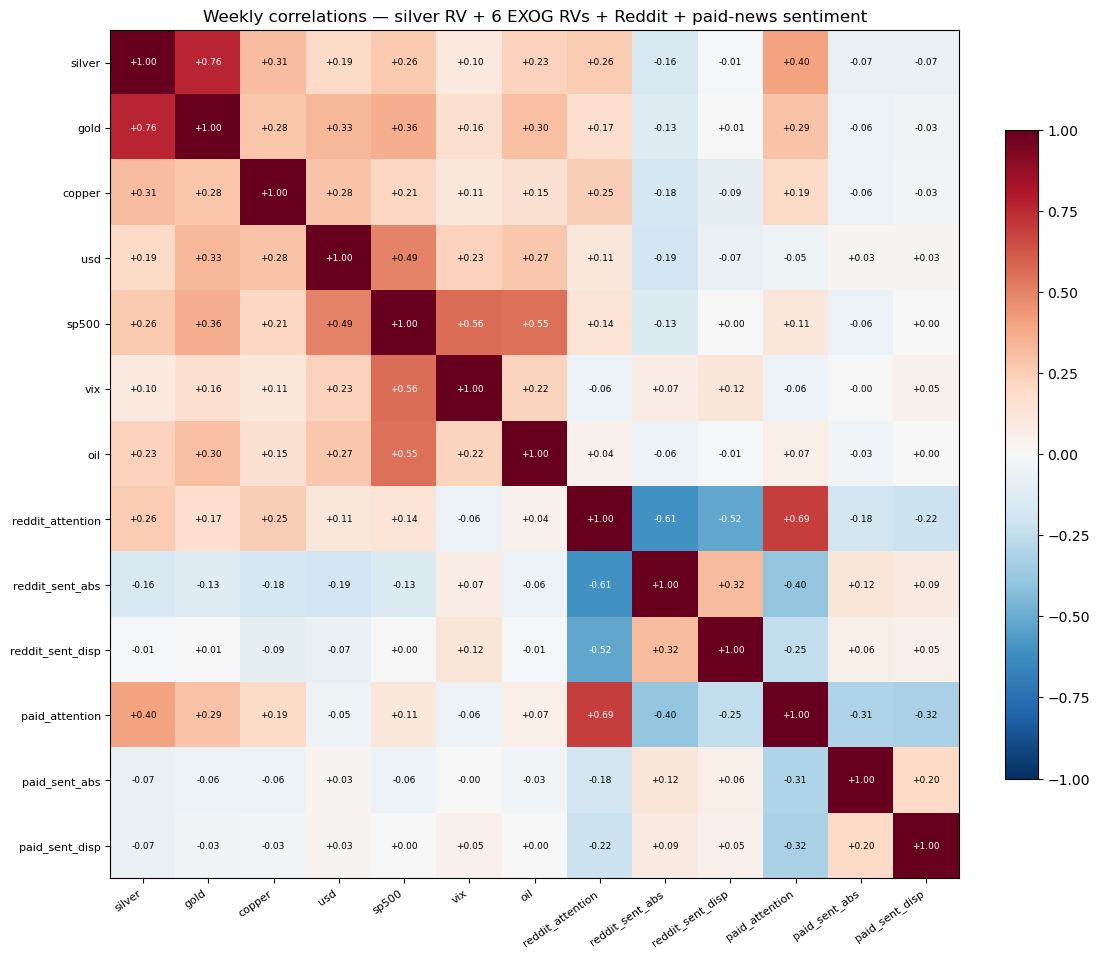

silver_rv correlation with each predictor (sorted by |r|):
gold_rv             0.759
paid_attention      0.404
copper_rv           0.311
sp500_rv            0.265
reddit_attention    0.255
oil_rv              0.233
usd_rv              0.192
reddit_sent_abs    -0.164
vix_rv              0.098
paid_sent_disp     -0.072
paid_sent_abs      -0.072
reddit_sent_disp   -0.008

strongest internal pair (by |corr|): reddit_attention <-> paid_attention = +0.694


In [56]:
_sent_daily = pd.read_csv('../../data/processed/daily_sentiment.csv',
                          parse_dates=['date']).set_index('date')
_sg = _sent_daily.resample('W-FRI')
_sent_w = pd.DataFrame({
    'reddit_attention': np.log1p(_sg['reddit_post_count'].sum()),
    'reddit_sent_abs' : _sg['reddit_sentiment'].mean().abs(),
    'reddit_sent_disp': _sg['reddit_sentiment'].std(),
    'paid_attention'  : np.log1p(_sg['news_paid_article_count'].sum()),
    'paid_sent_abs'   : _sg['news_paid_sentiment_title'].mean().abs(),
    'paid_sent_disp'  : _sg['news_paid_sentiment_title'].std(),
})

_combined = pd.concat([rv, _sent_w], axis=1).dropna()
corr = _combined.corr()

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
labels = [c.replace('_rv', '') for c in corr.columns]   # keep reddit_/paid_ prefix for clarity
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:+.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=6.5)
ax.set_title('Weekly correlations — silver RV + 6 EXOG RVs + Reddit + paid-news sentiment')
fig.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout(); plt.show()

print('silver_rv correlation with each predictor (sorted by |r|):')
_sc = corr['silver_rv'].drop('silver_rv')
print(_sc.reindex(_sc.abs().sort_values(ascending=False).index).round(3).to_string())

_others = corr.drop(index='silver_rv', columns='silver_rv')
_off_diag = _others.where(~np.eye(len(_others), dtype=bool))
_pair = _off_diag.abs().stack().idxmax()
print(f"\nstrongest internal pair (by |corr|): "
      f"{_pair[0]} <-> {_pair[1]} = {_others.loc[_pair[0], _pair[1]]:+.3f}")

### 2.5 Lagged predictive correlations

Each candidate predictor at $t{-}1$ vs the silver-RV target at $t$. Two views: (left)
the full correlation matrix among lagged predictors and the target; (right) the sorted
bar chart of the predictor → `silver_rv`($t$) row alone — the single most useful EDA
for HAR-X model selection. Mirrors the analogous lagged-correlation cell in the
returns chapter (`notebooks/02_features.ipynb`).

Includes all EDA sentiment/attention sources: Reddit (attention + intensity + disp),
paid news (same three constructs), and Google Trends (log-SVI). Lead-lag correlations
are *much* smaller than the contemporaneous ones in §2.4 — co-movement ≠ predictive
power. Colormap (`RdBu_r`) deliberately matches §2.4.

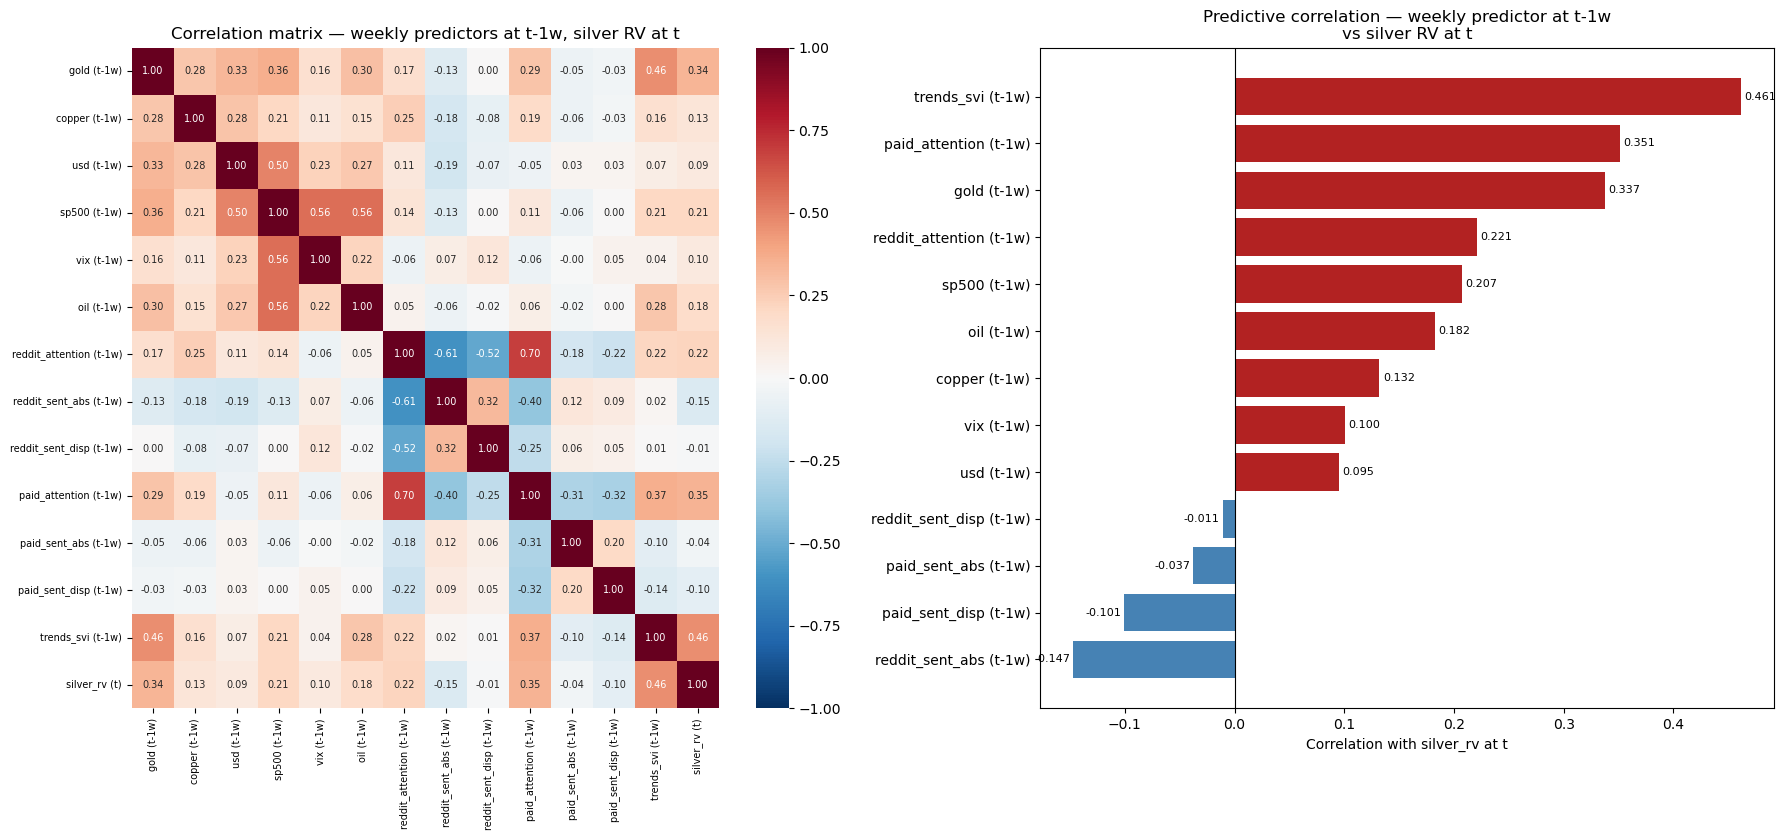

1-week predictive correlations with silver_rv at t (predictors at t-1w):
reddit_sent_abs (t-1w)    -0.146931
paid_sent_disp (t-1w)     -0.100545
paid_sent_abs (t-1w)      -0.037475
reddit_sent_disp (t-1w)   -0.010764
usd (t-1w)                 0.094791
vix (t-1w)                 0.100373
copper (t-1w)              0.132060
oil (t-1w)                 0.182485
sp500 (t-1w)               0.207067
reddit_attention (t-1w)    0.221261
gold (t-1w)                0.337401
paid_attention (t-1w)      0.351152
trends_svi (t-1w)          0.461211


In [57]:
import seaborn as sns

_exog_lag  = rv.drop(columns='silver_rv').shift(1).rename(
    columns=lambda c: c.replace('_rv', '') + ' (t-1w)')
_sent_lag  = _sent_w.shift(1).rename(columns=lambda c: c + ' (t-1w)')

# Trends (log-SVI) — read fresh to avoid collision with §5c's raw `trends_w`
_tr_lagged = '../../data/raw/google_trends.csv'
if os.path.exists(_tr_lagged):
    _tr_raw = pd.read_csv(_tr_lagged, index_col=0, parse_dates=True)
    _tr_raw.index = _tr_raw.index.tz_localize(None)
    _trends_lag = (np.log(_tr_raw['trends_silver']).resample('W-FRI').mean()
                   .shift(1).rename('trends_svi (t-1w)'))
    _lagged = pd.concat([_exog_lag, _sent_lag, _trends_lag.to_frame()], axis=1)
else:
    _lagged = pd.concat([_exog_lag, _sent_lag], axis=1)

_lagged['silver_rv (t)'] = rv['silver_rv']            # target always last column
_lag_corr = _lagged.dropna().corr()

predictors = [c for c in _lag_corr.columns if c != 'silver_rv (t)']
lag_row = _lag_corr.loc[predictors, 'silver_rv (t)'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, max(7, len(predictors) * 0.5 + 2)))

sns.heatmap(_lag_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('Correlation matrix — weekly predictors at t-1w, silver RV at t')
axes[0].tick_params(labelsize=7)

colors = ['steelblue' if v < 0 else 'firebrick' for v in lag_row.values]
axes[1].barh(lag_row.index, lag_row.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with silver_rv at t')
axes[1].set_title('Predictive correlation — weekly predictor at t-1w\nvs silver RV at t')
for v, name in zip(lag_row.values, lag_row.index):
    axes[1].text(v + 0.003 * (1 if v >= 0 else -1), name, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('1-week predictive correlations with silver_rv at t (predictors at t-1w):')
print(lag_row.to_string())

## 3. HAR features + EXOG cross-asset RVs

The model-specific notebooks all draw from the same feature frame built here.

**HAR features.** The HAR-RV model (Corsi 2009 — see `02_har.ipynb` for the full model
description) regresses RV on trailing averages over several horizons. The name is short
for the *Heterogeneous Autoregressive* model of realised volatility: it assumes market
participants act on different time horizons — short-term traders react to last week,
medium-term traders to last month, longer-term traders to last quarter — so the
volatility observed today reflects all of those horizons at once. For the **weekly**
target we build three trailing averages of past RV:

- $\text{RV}^{(w)}_{t-1}$ — last week's RV (short horizon)
- $\text{RV}^{(m)}_{t-1}$ — 4-week trailing mean (≈ 1 month, medium horizon)
- $\text{RV}^{(q)}_{t-1}$ — 12-week trailing mean (≈ 1 quarter, long horizon)

All three apply `.shift(1)` first, so only information available at the end of week
$t-1$ enters the week-$t$ prediction — no intra-week look-ahead.

**EXOG features.** The tree models (`03`, `04`) additionally get 1-week lags of the
cross-asset RVs — gold, copper, USD, S&P 500, VIX, oil — to test whether volatility
spills over across asset classes. HAR-RV and GARCH stay univariate.


In [58]:
def har_features(rv_series):
    """Three HAR trailing averages of past RV (short / medium / long horizon), all lagged 1 week."""
    df = pd.DataFrame(index=rv_series.index)
    df['rv_w_lag1'] = rv_series.shift(1)
    df['rv_m_lag1'] = rv_series.shift(1).rolling(4).mean()
    df['rv_q_lag1'] = rv_series.shift(1).rolling(12).mean()
    return df

har = har_features(rv['silver_rv'])

# EXOG: 1-week lag of each cross-asset RV
exog_vol = pd.DataFrame(index=rv.index)
for c in rv.columns:
    if c == 'silver_rv':
        continue
    exog_vol[c.replace('_rv', '_rv_lag1')] = rv[c].shift(1)

# silver_ret = weekly silver log-return, kept for the GARCH notebook (it models returns, not RV)
frame = pd.concat([rv[['silver_rv']].rename(columns={'silver_rv': 'target'}),
                   har, exog_vol,
                   silver_w_ret.rename('silver_ret')], axis=1).dropna()
print(f'Modelling frame: {len(frame)} obs, {frame.shape[1]-1} columns besides target')
frame.head()


Modelling frame: 579 obs, 10 columns besides target


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1,silver_ret
Date,,,,,,,,,,,
2015-04-03,0.042182,0.010778,0.029519,0.038292,0.010026,0.021660,0.010662,0.016350,0.140043,0.084681,-0.021697
2015-04-10,0.042694,0.042182,0.033638,0.038498,0.025166,0.015996,0.011257,0.015943,0.072036,0.059034,-0.019120
2015-04-17,0.012582,0.042694,0.038844,0.037551,0.021050,0.020324,0.014129,0.010077,0.095041,0.098479,-0.009144
2015-04-24,0.028814,0.012582,0.027059,0.036942,0.011268,0.022176,0.012719,0.013421,0.157165,0.065134,-0.037051
2015-05-01,0.059376,0.028814,0.031568,0.032544,0.024591,0.033291,0.009486,0.011093,0.064794,0.040856,0.030246


### Which model uses which column

`frame` is the single source every volatility notebook draws from — each model then
picks its own subset of these columns:

| Column(s) | HAR-RV (`01`) | GARCH (`02`) | RF (`03`) | XGB (`04`) | Naïve (`01`) |
|---|:--:|:--:|:--:|:--:|:--:|
| `target` (silver RV) | predicted | predicted | predicted | predicted | predicted |
| `rv_w_lag1` | feature | — | feature | feature | **is the forecast** |
| `rv_m_lag1`, `rv_q_lag1` | feature | — | feature | feature | — |
| `*_rv_lag1` (6 EXOG cross-asset RVs) | — | — | feature | feature | — |
| `reddit_*_lag1` (3 sentiment, built §5) | ablation | — | ablation | ablation | — |
| `silver_ret` | — | fit input | — | — | — |

- **HAR-RV** — OLS of `target` on the three HAR lags only (`rv_w/m/q_lag1`); ignores
  EXOG and `silver_ret`.
- **GARCH(1,1)** — does *not* touch the RV features at all; it fits on the weekly
  return series `silver_ret` and uses its one-step-ahead conditional volatility as the
  RV forecast.
- **RF / XGB** — `target` on HAR + EXOG (9 features); the only models that see the
  cross-asset RV lags.
- **Naïve** — no fitting: the forecast *is* `rv_w_lag1` (= RV_{t-1}).
- **Sentiment** — the three `reddit_*_lag1` columns (built in §5) are consumed only by
  the *sentiment-ablation* sections of `01` / `03` / `04`; the headline models above
  never see them, so the cross-model comparison is unaffected. **GARCH is excluded
  deliberately**: a standard GARCH(1,1) takes no exogenous regressors in its variance
  equation, and the `arch` package supports exogenous variables only in the *mean*
  equation. A proper sentiment-in-variance test would need a GARCH-X or GARCH-MIDAS
  formulation (Engle, Ghysels & Sohn 2013), which is out of scope here — GARCH stays as
  the parametric univariate baseline.

`rv_w_lag1` does double duty — besides being a HAR feature and the Naïve forecast, it
is the `prev_actual` baseline (RV_{t-1}) that every notebook's DCA and QLIKE-DM
evaluation measures change against. The `split` column added in §4 just labels each
row `train` / `val` / `test`; it is not a model input.

## 4. Train / val / test split

Matches the rest of the thesis: train ≤ 2021-12-31, val = 2022, test ≥ 2023-01-01.
The split is recorded as a `split` column so every model notebook reuses exactly the
same partition without re-deriving it.

In [59]:
TR_END  = '2021-12-31'
VAL_END = '2022-12-31'

frame['split'] = 'test'
frame.loc[frame.index <= TR_END, 'split'] = 'train'
frame.loc[(frame.index > TR_END) & (frame.index <= VAL_END), 'split'] = 'val'

print(frame['split'].value_counts().reindex(['train', 'val', 'test']))

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
print('\nHAR  features:', FEATS_HAR)
print('EXOG features:', FEATS_EXOG)

split
train    353
val       52
test     174
Name: count, dtype: int64

HAR  features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
EXOG features: ['gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 5. Sentiment + attention features (Reddit + Paid News + Google Trends) — for the volatility ablation

The models above use only the price series' own past. A separate question — taken up
as an *ablation* in `02_har`, `03_random_forest` and `04_xgboost` — is whether **public
sentiment** carries incremental information for next week's RV. The motivation is the
well-documented news→volatility channel (Engle & Ng 1993): public information flow
moves the *second* moment of returns far more reliably than the first, so sentiment is
a more natural input to a volatility model than to a return model. The closest
published precedent is Audrino, Sigrist & Ballinari (2020), who add sentiment and
attention features to volatility models and evaluate them under proxy-robust losses;
their finding is a real but modest incremental effect, which is the bar this ablation
tests against.

Four distinct source groups are kept **separate** so the ablation can attribute any
effect to one or the other:

- **Reddit attention** — weekly post volume (`reddit_attention`), log1p-transformed.
  Attention drives trading activity and hence volatility (Da, Engelberg & Gao 2011).
- **Reddit sentiment intensity** — `reddit_sent_abs` = |weekly-mean tone| (sign dropped
  because for *volatility* only the magnitude matters) and `reddit_sent_disp` =
  within-week std of daily tone (a disagreement proxy).
- **Paid news (NewsAPI.ai / Event Registry)** — reputable-source silver news,
  FinBERT-scored on the title (same encoding as the returns chapter, CLAUDE.md §4).
  Three parallel features: `paid_attention` (log article count), `paid_sent_abs`
  (|mean title sentiment|), `paid_sent_disp` (within-week std).
  Near-full coverage — 2 zero-article weeks in 598 total, 0 in the test period.
- **Search attention (Google Trends)** — `trends_lag1`, log Google search interest in
  *silver* (W-FRI mean, Da, Engelberg & Gao 2011 log-SVI form). A broad-retail channel
  only ~0.3 correlated with Reddit attention, so it is not redundant.

**GDELT excluded.** GDELT silver-headline coverage is too sparse: begins late 2017 with
≈20 zero-article weeks inside the 2023–26 test window. Recorded as a data limitation.

**No look-ahead.** All features are aggregated W-FRI (sum for counts, mean/std for
scores) then `.shift(1)`-ed — exactly like the HAR lags — so only week-$t{-}1$
information enters the week-$t$ forecast. Joined after the split; NaN only on sample
boundary weeks (2015 start and the final 2026 week).

In [60]:
# --- Weekly Reddit sentiment features (W-FRI, same calendar as the RV frame) ---
sent_daily = pd.read_csv('../../data/processed/daily_sentiment.csv',
                         parse_dates=['date']).set_index('date')

g = sent_daily.resample('W-FRI')
sent_w = pd.DataFrame({
    # log1p: weekly post volume is heavily right-skewed (median ~330, max ~9k); the
    # log compresses the tail so a handful of viral weeks don't dominate the OLS fit,
    # matching the log-SVI convention in Da, Engelberg & Gao (2011).
    'reddit_attention': np.log1p(g['reddit_post_count'].sum()),
    'reddit_sent_abs' : g['reddit_sentiment'].mean().abs(),      # |net tone|, sign dropped
    'reddit_sent_disp': g['reddit_sentiment'].std(),             # within-week tone dispersion
})
sent_lag = sent_w.shift(1)                       # lag 1w -> known at close of week t-1
sent_lag.columns = [c + '_lag1' for c in sent_lag.columns]

frame = frame.join(sent_lag)                     # left join; NaN only on boundary weeks

# --- Paid news (NewsAPI.ai / Event Registry) — reputable-source silver news ---
# Three features parallel to Reddit: attention (log article volume), tone intensity
# (|mean FinBERT title sentiment|, sign dropped), tone dispersion (within-week std).
# Title encoding follows the returns chapter convention (CLAUDE.md §4).
# 2 zero-article weeks in the full sample (0 in test) — NaN filled by dropna in ablation.
paid_w = pd.DataFrame({
    'paid_attention': np.log1p(g['news_paid_article_count'].sum()),
    'paid_sent_abs' : g['news_paid_sentiment_title'].mean().abs(),
    'paid_sent_disp': g['news_paid_sentiment_title'].std(),
})
paid_lag = paid_w.shift(1)
paid_lag.columns = [c + '_lag1' for c in paid_lag.columns]

frame = frame.join(paid_lag)

# --- Google Trends "silver" search interest — a second (broad retail) attention proxy ---
# Sibling to reddit_attention (Reddit-specific). log-SVI form (Da, Engelberg & Gao 2011):
# log compresses the 2021 squeeze spike and matches reddit_attention's log treatment.
# W-FRI mean (Trends is Sunday-stamped weekly), then .shift(1) -> known at close of t-1.
_tr = pd.read_csv('../../data/raw/google_trends.csv', index_col=0, parse_dates=True)
_tr.index = _tr.index.tz_localize(None)
trends_w  = np.log(_tr['trends_silver']).resample('W-FRI').mean()
frame['trends_lag1'] = trends_w.reindex(frame.index).shift(1)
FEATS_TRENDS = ['trends_lag1']
print('Trends feature added:', FEATS_TRENDS)

FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1', 'reddit_sent_disp_lag1']
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT

FEATS_PAID_ATTN = ['paid_attention_lag1']
FEATS_PAID_INT  = ['paid_sent_abs_lag1']   # paid_sent_disp_lag1 built but pending EDA
FEATS_PAID      = FEATS_PAID_ATTN + FEATS_PAID_INT

print('Sentiment features:', FEATS_SENT)
print('Paid-news features:', FEATS_PAID)
print('NaN per column (boundary / zero-article weeks):')
print(frame[FEATS_SENT + FEATS_TRENDS + FEATS_PAID + ['paid_sent_disp_lag1']].isna().sum().to_string())

frame.to_csv('../../data/processed/volatility_weekly.csv', index_label='Date')
print(f'\nSaved -> data/processed/volatility_weekly.csv  '
      f'({len(frame)} rows, {frame.shape[1]} columns)')
frame.tail(3)

Trends feature added: ['trends_lag1']
Sentiment features: ['reddit_attention_lag1', 'reddit_sent_abs_lag1', 'reddit_sent_disp_lag1']
Paid-news features: ['paid_attention_lag1', 'paid_sent_abs_lag1']
NaN per column (boundary / zero-article weeks):
reddit_attention_lag1     0
reddit_sent_abs_lag1      1
reddit_sent_disp_lag1     1
trends_lag1               1
paid_attention_lag1       0
paid_sent_abs_lag1        2
paid_sent_disp_lag1      11

Saved -> data/processed/volatility_weekly.csv  (579 rows, 19 columns)


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1,silver_ret,split,reddit_attention_lag1,reddit_sent_abs_lag1,reddit_sent_disp_lag1,paid_attention_lag1,paid_sent_abs_lag1,paid_sent_disp_lag1,trends_lag1
Date,,,,,,,,,,,,,,,,,,,
2026-04-17,0.065265,0.049648,0.076046,0.120464,0.022530,0.044257,0.007139,0.02594,0.227223,0.183591,0.068532,test,6.054439,0.227956,0.275243,4.060443,0.083868,0.245062,3.415412
2026-04-24,0.063699,0.065265,0.068891,0.117956,0.023990,0.024521,0.004368,0.02128,0.051218,0.153298,-0.067759,test,6.120297,0.184844,0.122927,4.204693,0.013386,0.137877,3.409214
2026-05-01,0.056671,0.063699,0.063650,0.088795,0.027002,0.025807,0.005495,0.01532,0.096217,0.080207,-0.005672,test,6.001415,0.224617,0.172927,4.127134,0.155114,0.235537,3.018547


### 5b. Sentiment-feature EDA

Three diagnostics on the just-built Reddit features, each tied to a modelling claim:

- **Attention time series** — does the series behave like a sensible retail-engagement
  proxy? The Feb-2021 silver-squeeze week is annotated as a known-event sanity check;
  it sits in the *train* sample so it is a motivating example, not test-period evidence.
- **Distribution of raw weekly post counts** — the right-skew that justifies the
  `log1p` transform in §5's feature build (matches the log-SVI convention in Da,
  Engelberg & Gao 2011).
- **Sentiment-feature correlation heatmap** — quantifies the "three views of the same
  latent Reddit engagement level" claim that explains the combined-sentiment-rung
  redundancy in `02_har` §5 (attention ≈ −0.6 with each intensity feature).

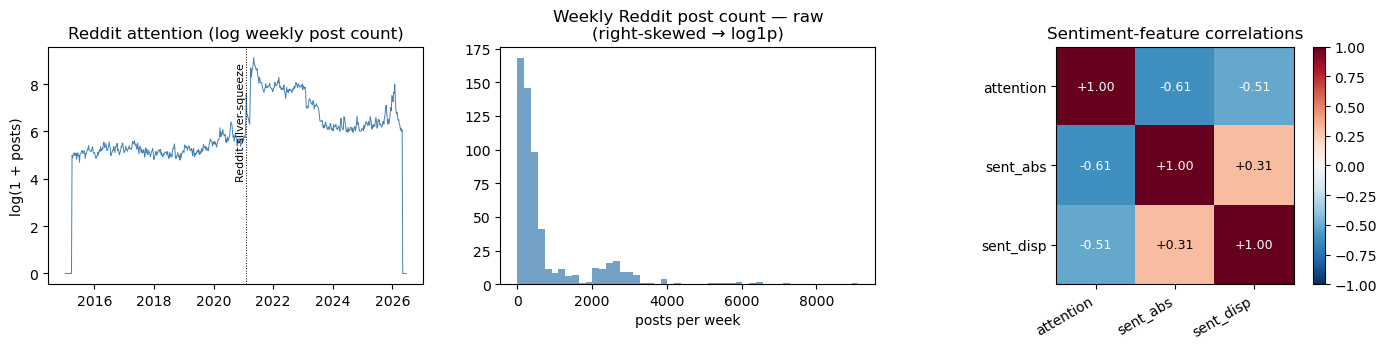

raw weekly post count: median=315  mean=821  max=9126   max/median = 29.0x
Note: the Feb-2021 silver-squeeze week sits in the *train* sample — this is a motivating example, not test-period evidence.


In [61]:
# 5b -- Sentiment-feature EDA: attention time series with the 2021 squeeze annotated,
# raw-count distribution that motivates log1p, and the 3-feature correlation matrix
# that explains the combined-rung redundancy in 02_har §5.
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

# (1) attention time series -- unlagged, the actual Reddit history
att = sent_w['reddit_attention']
ax[0].plot(att.index, att, color='steelblue', lw=0.7)
ax[0].axvline(pd.Timestamp('2021-02-05'), color='black', ls=':', lw=0.7)
ax[0].text(pd.Timestamp('2021-02-05'), att.max() * 0.98,
           'Reddit silver-squeeze', fontsize=8, ha='right', rotation=90, va='top')
ax[0].set_title('Reddit attention (log weekly post count)')
ax[0].set_ylabel('log(1 + posts)')

# (2) raw weekly post-count distribution -- the right-skew justifying log1p
raw_counts = np.expm1(sent_w['reddit_attention'])
ax[1].hist(raw_counts.dropna(), bins=50, color='steelblue', alpha=0.75)
ax[1].set_title('Weekly Reddit post count — raw\n(right-skewed → log1p)')
ax[1].set_xlabel('posts per week')

# (3) sentiment-feature correlations on the sample where all three exist
sent_corr = frame[FEATS_SENT].dropna().corr()
im = ax[2].imshow(sent_corr, vmin=-1, vmax=1, cmap='RdBu_r')
labels = [c.replace('reddit_', '').replace('_lag1', '') for c in FEATS_SENT]
ax[2].set_xticks(range(3)); ax[2].set_yticks(range(3))
ax[2].set_xticklabels(labels, rotation=30, ha='right'); ax[2].set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax[2].text(j, i, f'{sent_corr.iloc[i, j]:+.2f}', ha='center', va='center',
                   color='white' if abs(sent_corr.iloc[i, j]) > 0.5 else 'black',
                   fontsize=9)
ax[2].set_title('Sentiment-feature correlations')
fig.colorbar(im, ax=ax[2], fraction=0.04)

plt.tight_layout(); plt.show()

print(f"raw weekly post count: median={raw_counts.median():.0f}  "
      f"mean={raw_counts.mean():.0f}  max={raw_counts.max():.0f}   "
      f"max/median = {raw_counts.max()/raw_counts.median():.1f}x")
print('Note: the Feb-2021 silver-squeeze week sits in the *train* sample — this is a '
      'motivating example, not test-period evidence.')

### 5c. Google Trends — retail attention vs realised volatility

Google Trends search interest in silver is a second **attention** proxy alongside Reddit
post volume (§5). The Da, Engelberg & Gao (2011) attention→volatility channel predicts
attention should track the *second* moment (RV) rather than signed returns — so this is
tested here against RV, not returns (the analogous return scatter previously lived in
`01_eda`). Two lags (1w, 4w), over the full sample and the 2020–21 squeeze episode.

Trends **is** built into the feature frame in §5 as `trends_lag1` (log-SVI, lagged 1w) and
enters the `02_har` / `03` / `04` ablation ladders as the `HAR+Trends` and
`HAR+Attention+Trends` rungs — a second, broad-retail attention proxy alongside Reddit. The
scatters below are the motivating EDA. Requires `data/raw/google_trends.csv`
(`src/collection/collect_trends.py`); skips gracefully if the file is absent.

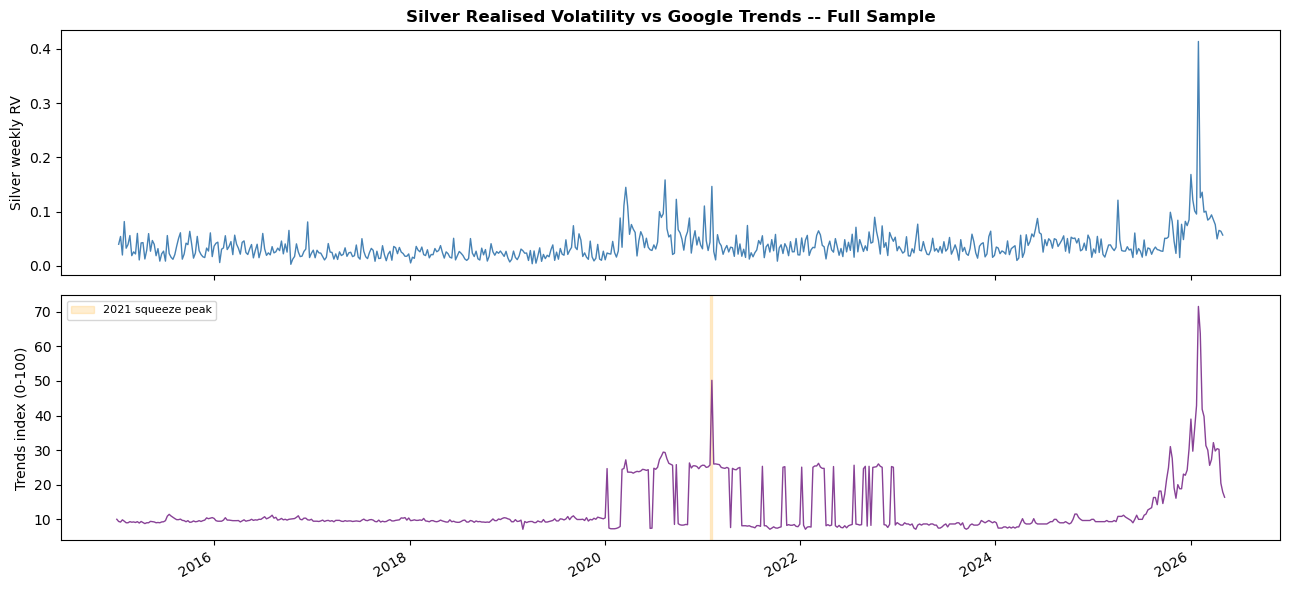

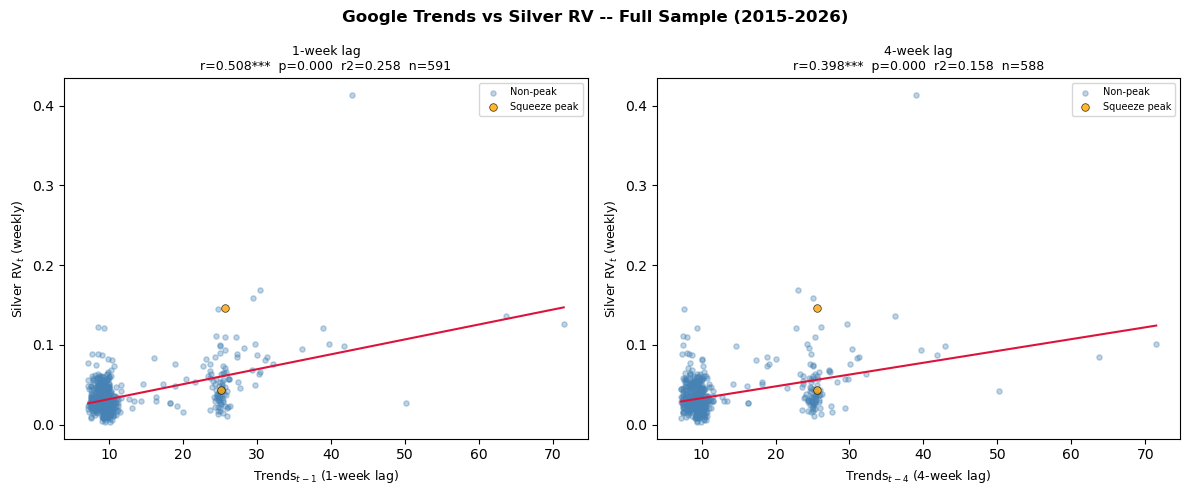


Summary -- Google Trends vs RV correlations:
  Window               Specification              r       r2        p
  --------------------------------------------------------------
  Full sample          1-week lag             0.508    0.258    0.000***
  Full sample          4-week lag             0.398    0.158    0.000***

* p<0.05  ** p<0.01  *** p<0.001
Attention (Trends) tracking RV is consistent with the attention->volatility channel.


In [62]:
# 5c -- Google Trends (retail attention) vs weekly RV, at 1w/4w lags, full sample and
# the 2020-21 squeeze episode. EDA only; Trends is not added to the feature frame.
trends_path = '../../data/raw/google_trends.csv'
if not os.path.exists(trends_path):
    print('google_trends.csv not found -- run src/collection/collect_trends.py first.')
else:
    trends = pd.read_csv(trends_path, index_col=0, parse_dates=True)
    trends.index = trends.index.tz_localize(None)
    trends_w  = trends['trends_silver'].resample('W-FRI').mean()
    rv_silver = rv['silver_rv']                       # weekly RV target (W-FRI)

    SQUEEZE_START = pd.Timestamp('2021-01-28')
    SQUEEZE_END   = pd.Timestamp('2021-02-05')

    def trends_scatter(ax, x_series, y_series, xlabel, ylabel, title):
        df = pd.concat([x_series, y_series], axis=1).dropna()
        if len(df) < 10:
            ax.text(0.5, 0.5, f'n={len(df)} -- insufficient', ha='center',
                    va='center', transform=ax.transAxes); ax.set_title(title); return None
        x, y = df.iloc[:, 0].values, df.iloc[:, 1].values
        r, p = scipy_stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        peak = (df.index >= SQUEEZE_START) & (df.index <= SQUEEZE_END)
        ax.scatter(x[~peak], y[~peak], alpha=0.35, s=14, color='steelblue', label='Non-peak')
        ax.scatter(x[peak], y[peak], alpha=0.8, s=30, color='orange',
                   edgecolors='black', lw=0.5, zorder=5, label='Squeeze peak')
        ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
        ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  r2={r**2:.3f}  n={len(df)}', fontsize=9)
        ax.legend(fontsize=7)
        return {'title': title, 'r': r, 'r2': r ** 2, 'p': p, 'n': len(df)}

    # Time series -- RV vs Trends (full sample)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax1.plot(rv_silver.index, rv_silver.values, lw=1, color='steelblue')
    ax1.set_ylabel('Silver weekly RV')
    ax1.set_title('Silver Realised Volatility vs Google Trends -- Full Sample', fontweight='bold')
    ax2.plot(trends_w.index, trends_w.values, lw=1, color='#7b2d8b', alpha=0.9)
    ax2.set_ylabel('Trends index (0-100)')
    ax2.axvspan(SQUEEZE_START, SQUEEZE_END, alpha=0.18, color='orange', label='2021 squeeze peak')
    ax2.legend(fontsize=8)
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()

    results_trends = []
    # Full-sample scatters
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Google Trends vs Silver RV -- Full Sample (2015-2026)', fontsize=12, fontweight='bold')
    for ax, lag, lab in [(axes[0], 1, '1-week lag'), (axes[1], 4, '4-week lag')]:
        r = trends_scatter(ax, trends_w.shift(lag), rv_silver.reindex(trends_w.index),
                           f'Trends$_{{t-{lag}}}$ ({lab})', 'Silver RV$_t$ (weekly)', lab)
        if r: r['window'] = 'Full sample'; results_trends.append(r)
    plt.tight_layout(); plt.show()

    if results_trends:
        print('\nSummary -- Google Trends vs RV correlations:')
        print(f'  {"Window":<20} {"Specification":<20} {"r":>7}  {"r2":>7}  {"p":>7}')
        print('  ' + '-' * 62)
        for row in results_trends:
            sig = '***' if row["p"] < 0.001 else '**' if row["p"] < 0.01 else '*' if row["p"] < 0.05 else ''
            print(f'  {row["window"]:<20} {row["title"]:<20} {row["r"]:>7.3f}  {row["r2"]:>7.3f}  {row["p"]:>7.3f}{sig}')
        print('\n* p<0.05  ** p<0.01  *** p<0.001')
        print('Attention (Trends) tracking RV is consistent with the attention->volatility channel.')

### 5d. Multi-lag predictive correlations — all sentiment / attention sources vs RV

`lag_xcorr` computes corr(silver_rv_t, x_{t-k}) for k = 0..8 weeks per feature. The
black-outlined bar marks the best predictive lag k ≥ 1. Primary purpose: verify that
lag 1 — used in all ablations — is not dominated by a later lag (which would indicate
a misspecified feature matrix).

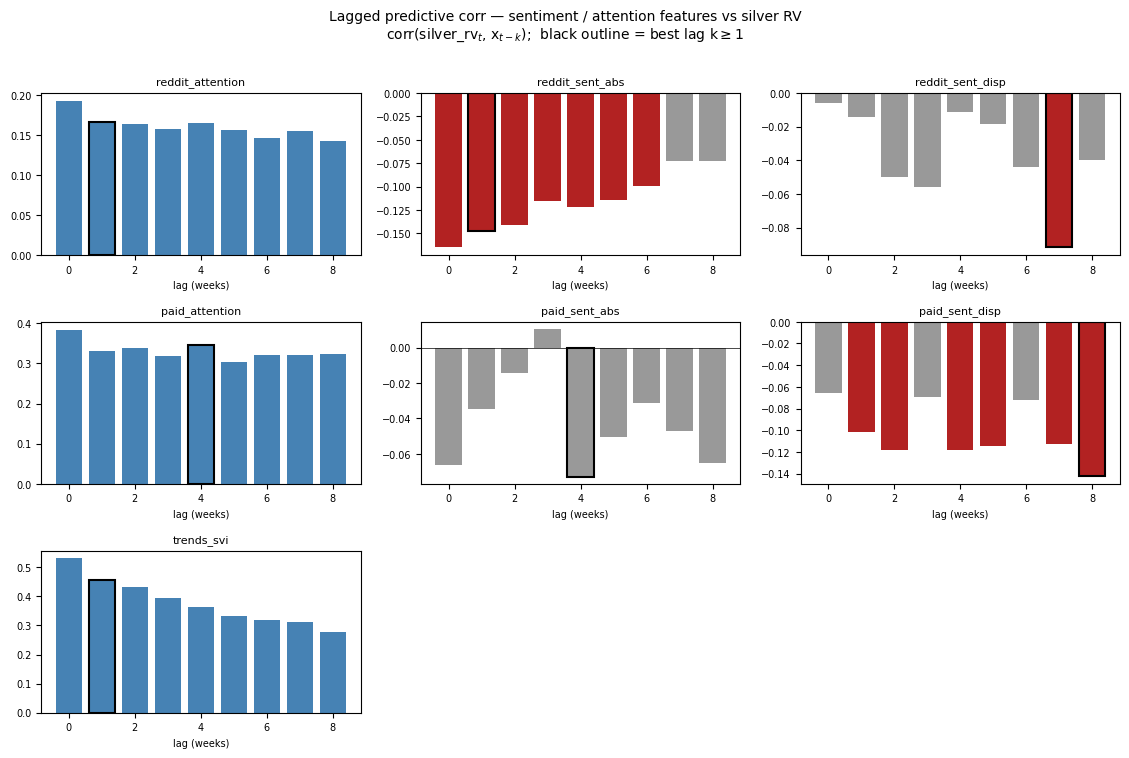


Best predictive lag per feature (k≥1, by |r|):
          series  best_lag  unit   corr     p   sig
      trends_svi         1 weeks  0.458 0.000  True
  paid_attention         4 weeks  0.346 0.000  True
reddit_attention         1 weeks  0.167 0.000  True
 reddit_sent_abs         1 weeks -0.148 0.000  True
  paid_sent_disp         8 weeks -0.142 0.001  True
reddit_sent_disp         7 weeks -0.092 0.028  True
   paid_sent_abs         4 weeks -0.073 0.079 False


In [63]:
from scipy.stats import pearsonr as _pr

def lag_xcorr(frame, target, preds, max_lag):
    rows = []
    for c in preds:
        for k in range(max_lag + 1):
            d = pd.concat([frame[target], frame[c].shift(k)], axis=1).dropna()
            if len(d) < 30: continue
            r, p = _pr(d.iloc[:, 0], d.iloc[:, 1])
            rows.append({'series': c, 'lag': k, 'corr': r, 'p': p, 'n': len(d)})
    return pd.DataFrame(rows)

def plot_lag_grid(xc, preds, unit, title, ncol=3):
    nrow = int(np.ceil(len(preds) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.8 * ncol, 2.5 * nrow), sharey=False)
    axes = np.atleast_1d(axes).flatten()
    best = []
    for ax, c in zip(axes, preds):
        d = xc[xc['series'] == c]
        ax.bar(d['lag'], d['corr'],
               color=['#999' if p > 0.05 else ('steelblue' if r > 0 else 'firebrick')
                      for r, p in zip(d['corr'], d['p'])])
        dp = d[d['lag'] >= 1]
        if not dp.empty:
            row = dp.loc[dp['corr'].abs().idxmax()]
            ax.bar([row['lag']], [row['corr']], color='none', edgecolor='black', lw=1.5, zorder=5)
            best.append({'series': c, 'best_lag': int(row['lag']), 'unit': unit,
                         'corr': round(row['corr'], 3), 'p': round(row['p'], 3)})
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
        ax.set_xlabel(f'lag ({unit})', fontsize=7)
    for ax in axes[len(preds):]: ax.axis('off')
    fig.suptitle(title, y=1.005, fontsize=10)
    plt.tight_layout(); plt.show()
    return pd.DataFrame(best)

# Unlagged feature series — lag_xcorr sweeps k=0..8 below.
# `sent_w` and `paid_w` are the un-lagged DataFrames built in the cell above.
# Trends: log-SVI (avoid collision with §5c's raw `trends_w` variable — read fresh).
_lg_tr_raw = pd.read_csv('../../data/raw/google_trends.csv', index_col=0, parse_dates=True)
_lg_tr_raw.index = _lg_tr_raw.index.tz_localize(None)
_lg_trends_svi = np.log(_lg_tr_raw['trends_silver']).resample('W-FRI').mean().rename('trends_svi')

_lg = pd.concat([rv[['silver_rv']], sent_w, paid_w, _lg_trends_svi], axis=1)
_lg_preds = list(sent_w.columns) + list(paid_w.columns) + ['trends_svi']

xc_lg = lag_xcorr(_lg, 'silver_rv', _lg_preds, max_lag=8)
best_lg = plot_lag_grid(xc_lg, _lg_preds, 'weeks',
    'Lagged predictive corr — sentiment / attention features vs silver RV\n'
    r'corr(silver_rv$_t$, x$_{t-k}$);  black outline = best lag k$\geq$1')
print('\nBest predictive lag per feature (k≥1, by |r|):')
print(best_lg.assign(sig=best_lg['p'] < 0.05)
             .sort_values('corr', key=abs, ascending=False)
             .to_string(index=False))